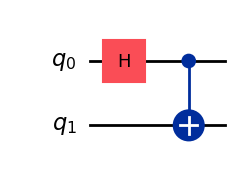

In [1]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.draw('mpl')


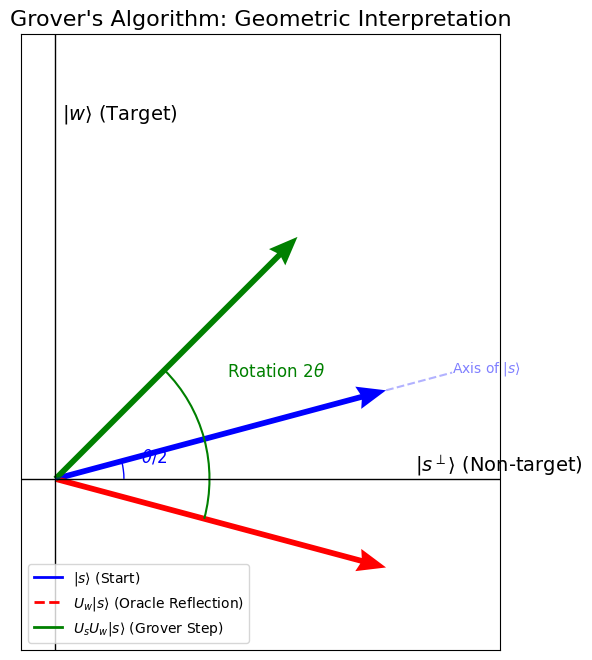

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Arc
from matplotlib.lines import Line2D  # Imported to fix the legend crash

def draw_grover_plot():
    # 1. Setup the Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Define the angle theta (half-angle alpha). 
    alpha = np.radians(15)  # 15 degrees
    r = 1.0  # Unit circle radius

    # 2. Define the State Vectors
    vec_s = np.array([np.cos(alpha), np.sin(alpha)])
    vec_oracle = np.array([np.cos(alpha), -np.sin(alpha)])
    vec_final = np.array([np.cos(3 * alpha), np.sin(3 * alpha)])

    # 3. Plotting Helper Function
    # We remove the label from the quiver to prevent auto-legend generation
    def plot_vector(vec, color, linestyle='-'):
        ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, 
                  color=color, width=0.012, headwidth=4, headlength=5, linestyle=linestyle)

    # 4. Draw Axes and Unit Circle
    ax.axhline(0, color='black', linewidth=1) # |s_perp> axis
    ax.axvline(0, color='black', linewidth=1) # |w> axis
    
    # Dashed line for |s> axis
    line_len = 1.2
    ax.plot([0, line_len * np.cos(alpha)], [0, line_len * np.sin(alpha)], 
            color='blue', linestyle='--', alpha=0.3)
    ax.text(line_len * np.cos(alpha), line_len * np.sin(alpha), r'Axis of $|s\rangle$', 
            fontsize=10, color='blue', alpha=0.5)

    # Draw vectors (No labels passed here to avoid the crash)
    plot_vector(vec_s, 'blue')
    plot_vector(vec_oracle, 'red', linestyle='--')
    plot_vector(vec_final, 'green')

    # 5. Add Annotations (Arcs and Labels)
    
    # Arc for initial angle
    arc_s = Arc((0,0), 0.4, 0.4, theta1=0, theta2=np.degrees(alpha), color='blue')
    ax.add_patch(arc_s)
    ax.text(0.25, 0.05, r'$\theta/2$', fontsize=12, color='blue')

    # Arc for rotation
    arc_rot = Arc((0,0), 0.9, 0.9, theta1=np.degrees(-alpha), theta2=np.degrees(3*alpha), 
                  color='green', linestyle='-', linewidth=1.5)
    ax.add_patch(arc_rot)
    ax.text(0.5, 0.3, r'Rotation $2\theta$', fontsize=12, color='green')

    # Axis Labels
    ax.text(1.05, 0.02, r'$|s^{\perp}\rangle$ (Non-target)', fontsize=14)
    ax.text(0.02, 1.05, r'$|w\rangle$ (Target)', fontsize=14)

    # 6. Create a Custom Legend (The Fix)
    # We create "Proxy Artists" - simple lines that stand in for the vectors in the legend
    legend_elements = [
        Line2D([0], [0], color='blue', lw=2, label=r'$|s\rangle$ (Start)'),
        Line2D([0], [0], color='red', lw=2, linestyle='--', label=r'$U_w|s\rangle$ (Oracle Reflection)'),
        Line2D([0], [0], color='green', lw=2, label=r'$U_s U_w |s\rangle$ (Grover Step)')
    ]
    ax.legend(handles=legend_elements, loc='lower left', frameon=True)

    # 7. Formatting
    ax.set_xlim(-0.1, 1.3)
    ax.set_ylim(-0.5, 1.3)
    ax.set_aspect('equal')
    ax.set_title("Grover's Algorithm: Geometric Interpretation", fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.show()

draw_grover_plot()

In [1]:
# Amplitude-encoding circuit image (Qiskit)
# Prepares a discretised distribution p(x) on N=2^n points via amplitudes sqrt(p).
#
# Output:
#   - amplitude_encoding_circuit.png (high-quality circuit image)
#
# Requires:
#   pip install qiskit matplotlib pylatexenc

import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from qiskit.visualization import circuit_drawer


# -------------------------
# 1) Discretise a distribution on N=2^n points
# -------------------------
n = 4                       # number of qubits -> N = 16 points
N = 2**n
x = np.linspace(-3, 3, N)   # grid points (example)

# Example distribution: discretised Gaussian (any nonnegative array works)
p = np.exp(-0.5 * x**2)
p = p / p.sum()             # normalise to a probability distribution

# Amplitude-encoding uses amplitudes a_i = sqrt(p_i)
amps = np.sqrt(p).astype(complex)
amps = amps / np.linalg.norm(amps)  # safety

# -------------------------
# 2) Build amplitude-encoding circuit
# -------------------------
qc = QuantumCircuit(n, name="Amplitude Encoding")
qc.append(StatePreparation(amps), range(n))
qc.barrier()

# Optional: measure (usually omitted for a "preparation" figure)
# qc.measure_all()

# -------------------------
# 3) Render to an image file
# -------------------------
circuit_drawer(
    qc,
    output="mpl",
    filename="amplitude_encoding_circuit.png",
    style={"font_size": 12},
    fold=-1
)

print("Saved: amplitude_encoding_circuit.png")


Saved: amplitude_encoding_circuit.png


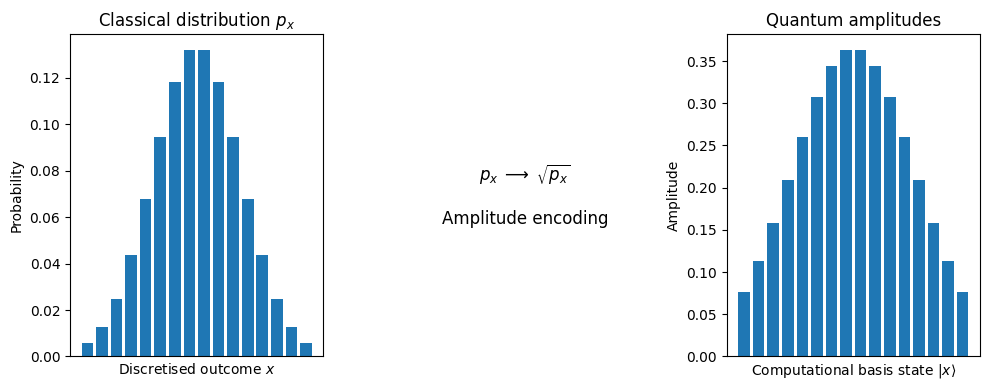

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Discretised distribution
# -------------------------
N = 16
x = np.arange(N)

# Example: discretised Gaussian (finance-style terminal prices)
p = np.exp(-0.5 * ((x - (N-1)/2) / 3)**2)
p /= p.sum()
amps = np.sqrt(p)

# -------------------------
# Figure layout
# -------------------------
fig = plt.figure(figsize=(10, 4))

# Left: classical distribution
ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(x, p)
ax1.set_title("Classical distribution $p_x$")
ax1.set_xlabel("Discretised outcome $x$")
ax1.set_ylabel("Probability")
ax1.set_xticks([])

# Middle: mapping arrow
ax2 = fig.add_subplot(1, 3, 2)
ax2.axis("off")
ax2.text(
    0.5, 0.5,
    r"$p_x \;\longrightarrow\; \sqrt{p_x}$" "\n\nAmplitude encoding",
    ha="center", va="center", fontsize=12
)

# Right: quantum state
ax3 = fig.add_subplot(1, 3, 3)
ax3.bar(x, amps)
ax3.set_title("Quantum amplitudes")
ax3.set_xlabel("Computational basis state $|x\\rangle$")
ax3.set_ylabel("Amplitude")
ax3.set_xticks([])

plt.tight_layout()
plt.savefig("amplitude_encoding_concept.png", dpi=300, bbox_inches="tight")
plt.show()


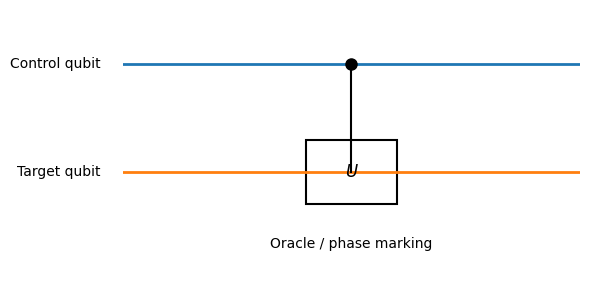

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))

# Draw qubit lines
ax.plot([0, 4], [1, 1], linewidth=2)   # control
ax.plot([0, 4], [0, 0], linewidth=2)   # target

# Control dot
ax.plot(2, 1, 'ko', markersize=8)

# Vertical connection
ax.plot([2, 2], [0, 1], 'k-', linewidth=1.5)

# Target box (controlled-U)
rect = plt.Rectangle((1.6, -0.3), 0.8, 0.6, fill=False, linewidth=1.5)
ax.add_patch(rect)
ax.text(2, 0, r"$U$", ha="center", va="center", fontsize=12)

# Labels
ax.text(-0.2, 1, r"Control qubit", ha="right", va="center")
ax.text(-0.2, 0, r"Target qubit", ha="right", va="center")

# Optional oracle annotation
ax.text(2, -0.7, r"Oracle / phase marking", ha="center", fontsize=10)

# Formatting
ax.set_xlim(0, 4)
ax.set_ylim(-1, 1.5)
ax.axis("off")

plt.tight_layout()
plt.savefig("controlled_U_oracle.png", dpi=300, bbox_inches="tight")
plt.show()


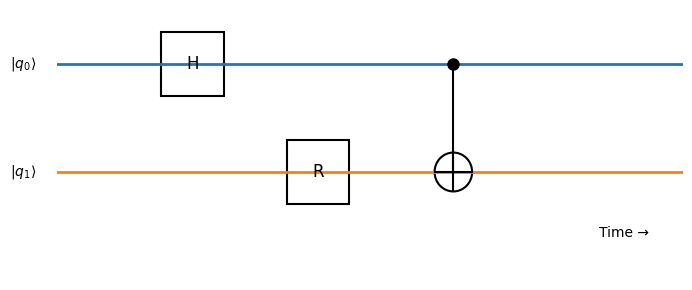

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7, 3))

# Qubit lines
ax.plot([0, 6], [1, 1], linewidth=2)
ax.plot([0, 6], [0, 0], linewidth=2)

# Single-qubit gate: Hadamard
h_gate = patches.Rectangle((1.0, 0.7), 0.6, 0.6, fill=False, linewidth=1.5)
ax.add_patch(h_gate)
ax.text(1.3, 1.0, "H", ha="center", va="center", fontsize=12)

# Single-qubit gate: Rotation
r_gate = patches.Rectangle((2.2, -0.3), 0.6, 0.6, fill=False, linewidth=1.5)
ax.add_patch(r_gate)
ax.text(2.5, 0.0, "R", ha="center", va="center", fontsize=12)

# CNOT control
ax.plot(3.8, 1, 'ko', markersize=8)

# Vertical connection
ax.plot([3.8, 3.8], [0, 1], 'k-', linewidth=1.5)

# CNOT target
circle = patches.Circle((3.8, 0), 0.18, fill=False, linewidth=1.5)
ax.add_patch(circle)
ax.plot([3.62, 3.98], [0, 0], 'k-', linewidth=1.5)
ax.plot([3.8, 3.8], [-0.18, 0.18], 'k-', linewidth=1.5)

# Labels
ax.text(-0.2, 1, r"$|q_0\rangle$", ha="right", va="center")
ax.text(-0.2, 0, r"$|q_1\rangle$", ha="right", va="center")

ax.text(5.2, -0.6, "Time →", fontsize=10)

# Formatting
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1.5)
ax.axis("off")

plt.tight_layout()
plt.savefig("basic_quantum_circuit.png", dpi=300, bbox_inches="tight")
plt.show()
